In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error




In [15]:
# 1. Load and prepare the data
# Load the CSV, parse the 'LocalTime' column as datetime, set it as the index, and enforce an hourly frequency.
df = pd.read_csv('../data/processed/pv_weather.csv', parse_dates=['LocalTime'])
df.set_index('LocalTime', inplace=True)
df = df.asfreq('h')



In [16]:
df

,Power(MW)_ActualEnergy,Power(MW)_DA,Power(MW)_HA4,T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR,ALLSKY_KT
LocalTime,,,,,,,,,,
2006-01-01 00:00:00,0.0,0.0,0.0,22.16,4.74,95.38,0.0,0.0,0.00,-999.0
2006-01-01 01:00:00,0.0,0.0,0.0,22.18,4.78,95.06,0.0,0.0,0.00,-999.0
2006-01-01 02:00:00,0.0,0.0,0.0,22.22,4.80,94.55,0.0,0.0,0.00,-999.0
2006-01-01 03:00:00,0.0,0.0,0.0,22.26,4.64,94.14,0.0,0.0,0.00,-999.0
2006-01-01 04:00:00,0.0,0.0,0.0,22.25,4.31,94.10,0.0,0.0,0.02,-999.0
...,...,...,...,...,...,...,...,...,...,...
2006-12-31 19:00:00,0.0,0.0,0.0,24.01,6.25,85.69,0.0,0.0,0.09,-999.0
2006-12-31 20:00:00,0.0,0.0,0.0,23.93,5.75,86.45,0.0,0.0,0.03,-999.0
2006-12-31 21:00:00,0.0,0.0,0.0,23.90,5.60,86.62,0.0,0.0,0.00,-999.0


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2415
[LightGBM] [Info] Number of data points in the train set: 6988, number of used features: 13
[LightGBM] [Info] Start training from score 47.175359
Test RMSE: 8.122348144624315
Test MAE: 4.0248434092738075


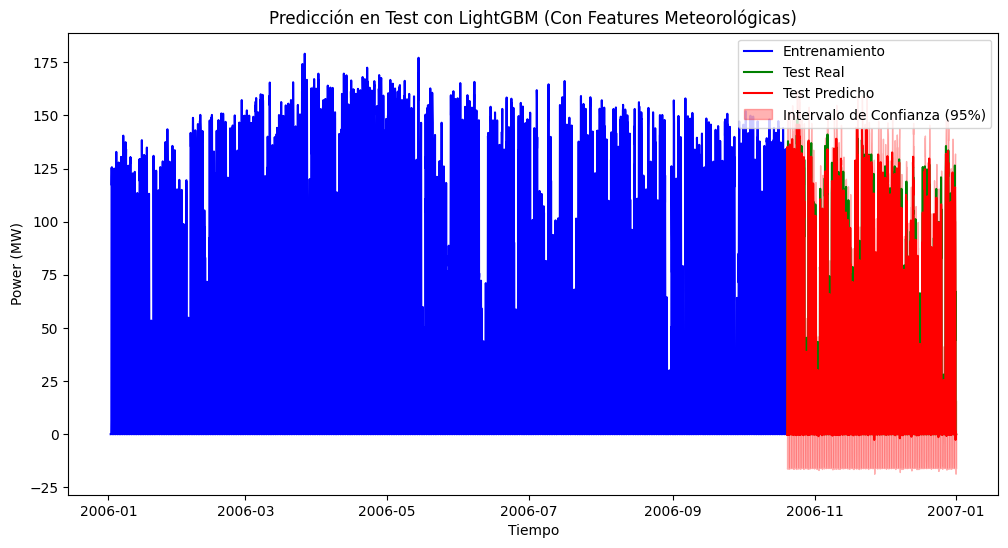

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Cargar y preparar los datos
df = pd.read_csv('../data/processed/pv_weather.csv', parse_dates=['LocalTime'])
df.set_index('LocalTime', inplace=True)
df = df.asfreq('h')  # Asegura frecuencia horaria

# 2. Ingeniería de características
# Ya suponemos que df contiene las columnas meteorológicas (T2M, WS10M, etc.).
# Creamos las columnas temporales y de lag si no existen todavía.
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

df['lag1'] = df['Power(MW)_ActualEnergy'].shift(1)
df['lag24'] = df['Power(MW)_ActualEnergy'].shift(24)
df['rolling_3'] = df['Power(MW)_ActualEnergy'].rolling(window=3).mean()

# Eliminamos filas con NaN generados por los shifts y rolling
df.dropna(inplace=True)

# 3. Definir variable objetivo y variables predictoras
target = 'Power(MW)_ActualEnergy'

# Lista de features (asegúrate de que existan en df)
features = [
    'T2M', 'WS10M', 'RH2M',
    'ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN',
    'PRECTOTCORR', 'ALLSKY_KT',
    'hour', 'dayofweek', 'month',
    'lag1', 'lag24', 'rolling_3'
]

X = df[features]
y = df[target]

# 4. Dividir los datos en entrenamiento y test (80% entrenamiento, 20% test)
train_size = int(len(df) * 0.8)
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

# 5. Entrenar el modelo LightGBM
model = lgb.LGBMRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# 6. Realizar predicciones sobre el conjunto de test
predictions = model.predict(X_test)

# 7. Calcular métricas: RMSE y MAE
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
print("Test RMSE:", rmse)
print("Test MAE:", mae)

# 8. Calcular intervalo de confianza aproximado (95%) basado en la desviación estándar de los residuos
residuals = y_test - predictions
resid_std = np.std(residuals)
upper_bound = predictions + 1.96 * resid_std
lower_bound = predictions - 1.96 * resid_std

# 9. Graficar
plt.figure(figsize=(12, 6))

# Línea de datos de entrenamiento
plt.plot(X_train.index, y_train, label='Entrenamiento', color='blue')

# Línea de datos reales de test
plt.plot(X_test.index, y_test, label='Test Real', color='green')

# Línea de predicción en test
plt.plot(X_test.index, predictions, label='Test Predicho', color='red')

# Área sombreada con intervalo de confianza
plt.fill_between(X_test.index, lower_bound, upper_bound, color='red', alpha=0.3, 
                 label='Intervalo de Confianza (95%)')

plt.title("Predicción en Test con LightGBM (Con Features Meteorológicas)")
plt.xlabel("Tiempo")
plt.ylabel("Power (MW)")
plt.legend()
plt.show()



In [8]:
df['y_pred_all'] = model.predict(X)

In [12]:
df[df['Power(MW)_ActualEnergy']>0]

,Power(MW)_ActualEnergy,Power(MW)_DA,Power(MW)_HA4,T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR,ALLSKY_KT,hour,dayofweek,month,lag1,lag24,rolling_3,y_pred,y_pred_all
LocalTime,,,,,,,,,,,,,,,,,,
2006-01-02 07:00:00,6.458333,0.0,0.0,22.73,4.83,88.80,29.83,29.92,0.00,0.32,7,0,1,0.000000,0.583333,2.152778,NaN,4.664909
2006-01-02 08:00:00,87.900000,0.5,0.2,23.10,5.04,87.63,160.85,161.10,0.00,0.44,8,0,1,6.458333,23.450000,31.452778,NaN,87.441152
2006-01-02 09:00:00,117.183333,41.9,78.8,23.34,5.20,86.36,392.52,409.48,0.01,0.65,9,0,1,87.900000,31.466667,70.513889,NaN,121.272147
2006-01-02 10:00:00,125.450000,111.3,96.4,23.54,5.18,85.16,508.27,560.75,0.03,0.65,10,0,1,117.183333,59.908333,110.177778,NaN,123.243973
2006-01-02 11:00:00,123.191667,114.3,117.9,23.63,5.01,84.68,609.90,656.25,0.03,0.68,11,0,1,125.450000,82.933333,121.941667,NaN,124.861655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 13:00:00,90.066667,120.9,113.3,24.83,6.59,78.27,382.40,625.78,0.02,0.43,13,6,12,108.325000,113.608333,104.138889,104.537600,104.537600
2006-12-31 14:00:00,75.208333,97.1,116.9,24.77,6.20,78.83,387.00,525.25,0.03,0.51,14,6,12,90.066667,81.575000,91.200000,86.013457,86.013457
2006-12-31 15:00:00,44.158333,95.7,110.0,24.68,6.08,79.55,296.77,370.50,0.02,0.52,15,6,12,75.208333,93.091667,69.811111,61.130660,61.130660


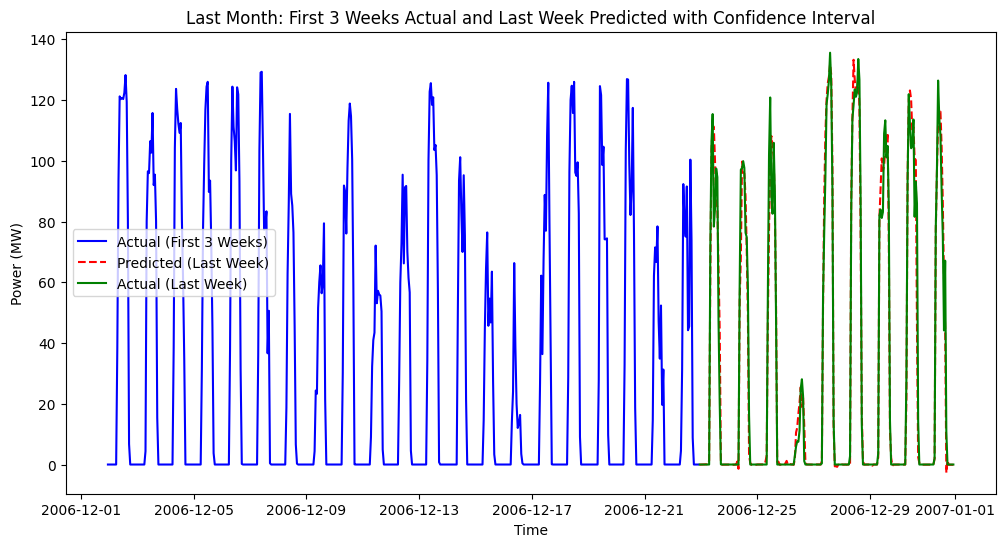

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Assumptions ---
# - df: DataFrame with a datetime index and a column 'Power(MW)_ActualEnergy'
# - df already contains a column 'y_pred' with the model's predictions
# - df also contains 'upper_bound' and 'lower_bound' columns for the 95% confidence interval
# ------------------------------------------------------------------------------

# 1. Extract the last month of data
end_date = df.index.max()
start_date = end_date - pd.Timedelta(days=30)
df_last_month = df.loc[start_date:end_date].copy()

# 2. Split the month into two parts:
#    - The first 3 weeks (21 days): actual data
#    - The last week (7 days): predicted data (and actual values for comparison)
first_3w_end = start_date + pd.Timedelta(days=21)
df_first_3w = df_last_month.loc[df_last_month.index < first_3w_end]
df_last_week = df_last_month.loc[df_last_month.index >= first_3w_end]

# 3. Plot the results:
plt.figure(figsize=(12, 6))

# Plot actual data for the first 3 weeks (blue line)
plt.plot(df_first_3w.index, df_first_3w['Power(MW)_ActualEnergy'],
         label='Actual (First 3 Weeks)', color='blue')

# Plot predicted values for the last week (red dashed line)
plt.plot(df_last_week.index, df_last_week['y_pred'],
         label='Predicted (Last Week)', color='red', linestyle='--')

# Optionally, plot the actual data for the last week for comparison (green line)
plt.plot(df_last_week.index, df_last_week['Power(MW)_ActualEnergy'],
         label='Actual (Last Week)', color='green')

# Plot the confidence interval as a shaded area, if available
if 'upper_bound' in df_last_week.columns and 'lower_bound' in df_last_week.columns:
    plt.fill_between(df_last_week.index,
                     df_last_week['lower_bound'],
                     df_last_week['upper_bound'],
                     color='red', alpha=0.3,
                     label='95% Confidence Interval')

plt.title("Last Month: First 3 Weeks Actual and Last Week Predicted with Confidence Interval")
plt.xlabel("Time")
plt.ylabel("Power (MW)")
plt.legend()
plt.show()
